# Telecom Customer Churn — Prediction & Business Risk Analysis

This notebook is organized into clear stages:

1. Setup & Data Loading
2. Initial Data Exploration
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Train/Test Split & Preprocessing
7. Baseline Random Forest Model
8. Random Forest Hyperparameter Tuning
9. XGBoost Model *(commented out — not used)*
10. XGBoost Hyperparameter Tuning *(commented out — not used)*
11. Model Interpretability (SHAP)
12. Business Risk Analysis
13. Final Pipeline & Model Export
14. Deployment Prep




## 1. Setup & Data Loading

In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Initial Data Exploration

In [4]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Churn'].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [10]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("-"*10)

customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
----------
gender
['Female' 'Male']
----------
SeniorCitizen
[0 1]
----------
Partner
['Yes' 'No']
----------
Dependents
['No' 'Yes']
----------
tenure
[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
----------
PhoneService
['No' 'Yes']
----------
MultipleLines
['No phone service' 'No' 'Yes']
----------
InternetService
['DSL' 'Fiber optic' 'No']
----------
OnlineSecurity
['No' 'Yes' 'No internet service']
----------
OnlineBackup
['Yes' 'No' 'No internet service']
----------
DeviceProtection
['No' 'Yes' 'No internet service']
----------
TechSupport
['No' 'Yes' 'No internet service']
----------
StreamingTV
['No' 'Yes' 'No internet service']
----------
StreamingMovies
['No' 'Yes' 'No internet service']
----------
Contract

## 3. Data Cleaning

In [11]:
(df['TotalCharges'] == ' ').sum()

np.int64(11)

In [12]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)

In [13]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [14]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# **EDA PROCESS**


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


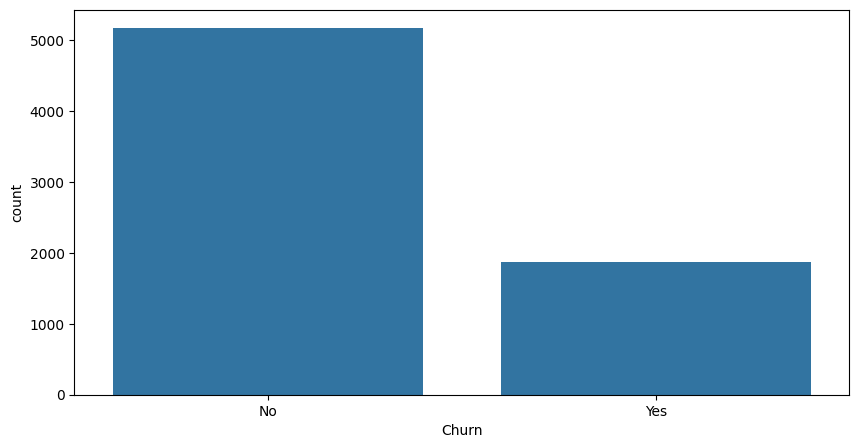

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='Churn', data=df)

print(df['Churn'].value_counts(normalize=True)*100)

In [17]:
num_cols = df.select_dtypes(include=['int','float']).columns
num_cols

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

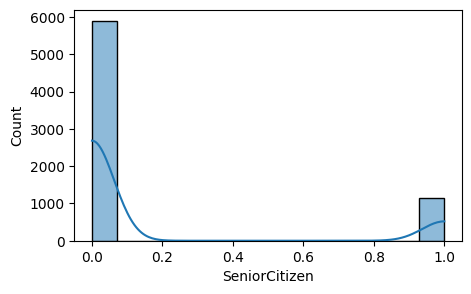

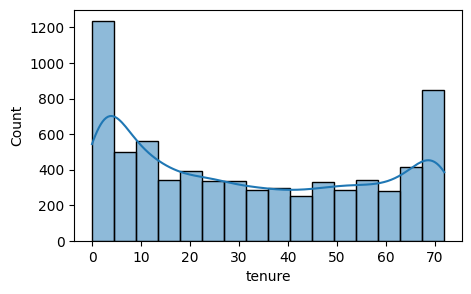

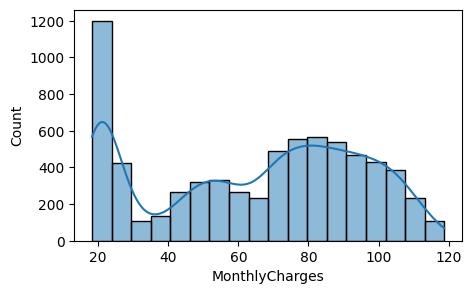

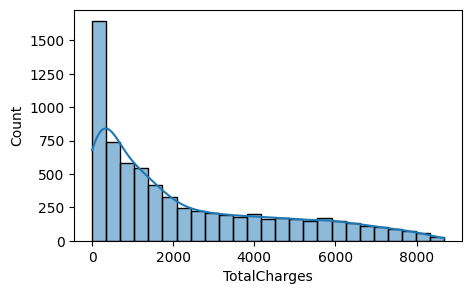

In [18]:
for cols in num_cols:
  plt.figure(figsize=(5,3))
  sns.histplot(df[cols], kde=True)
  plt.show()


In [19]:
df['SeniorCitizen'].skew()

np.float64(1.8336327440928564)

In [20]:
df['tenure'].skew()

np.float64(0.2395397495619829)

In [21]:
df['MonthlyCharges'].skew()

np.float64(-0.22052443394398033)

In [22]:
df['TotalCharges'].skew()

np.float64(0.963234654832277)

<Axes: xlabel='Contract', ylabel='count'>

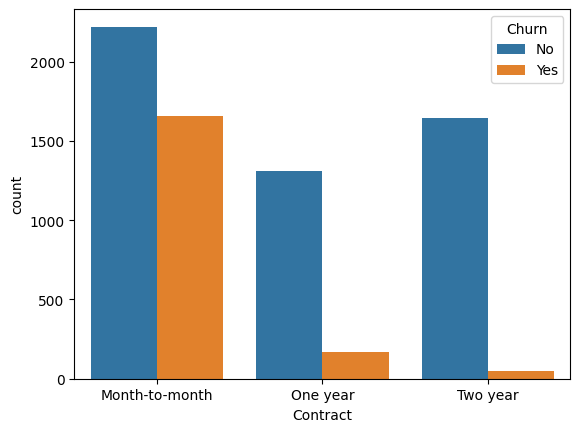

In [23]:
sns.countplot(x='Contract', hue='Churn', data=df)

In [24]:
pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize = 'index'
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [25]:
cat_cols = df.select_dtypes(include='object').columns

cat_cols

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')

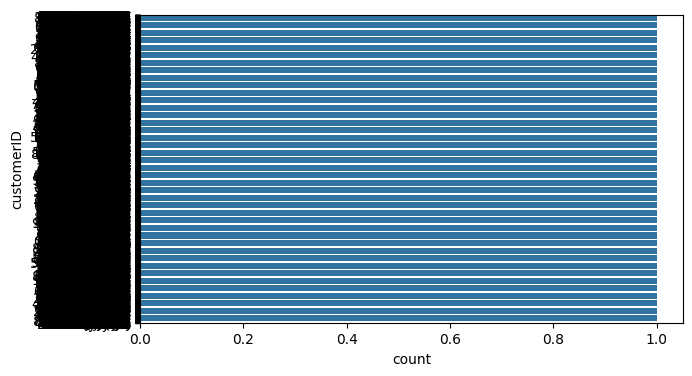

customerID
3186-AJIEK    0.014198
7590-VHVEG    0.014198
5575-GNVDE    0.014198
8775-CEBBJ    0.014198
2823-LKABH    0.014198
                ...   
6713-OKOMC    0.014198
1452-KIOVK    0.014198
9305-CDSKC    0.014198
9237-HQITU    0.014198
7795-CFOCW    0.014198
Name: proportion, Length: 7043, dtype: float64
--------------------------------------------------




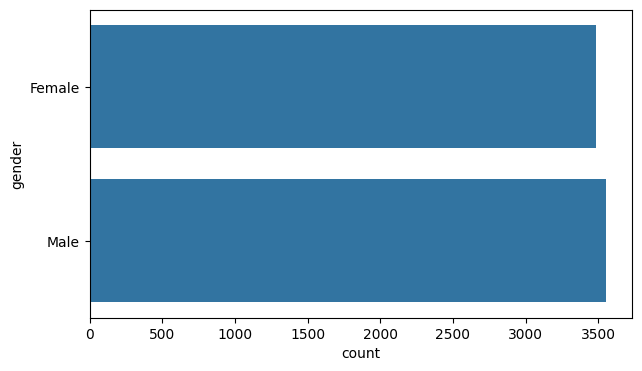

gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64
--------------------------------------------------




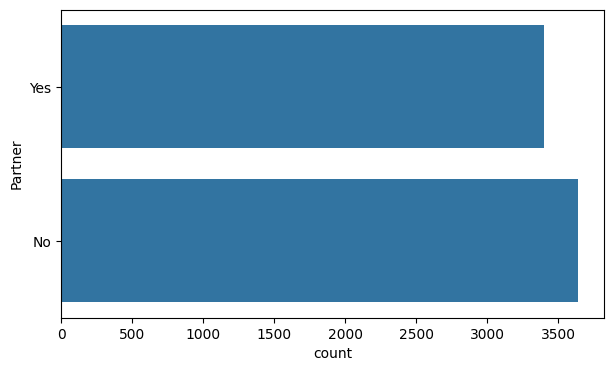

Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64
--------------------------------------------------




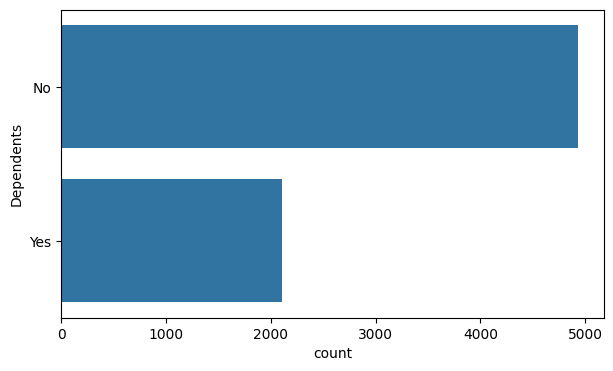

Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64
--------------------------------------------------




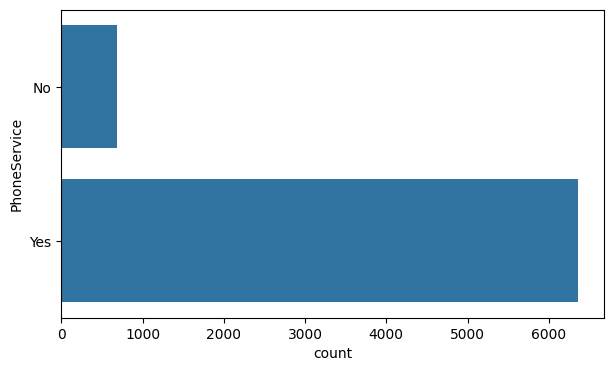

PhoneService
Yes    90.316626
No      9.683374
Name: proportion, dtype: float64
--------------------------------------------------




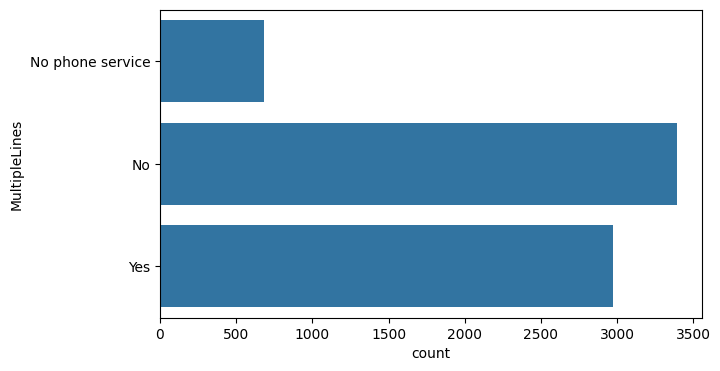

MultipleLines
No                  48.132898
Yes                 42.183729
No phone service     9.683374
Name: proportion, dtype: float64
--------------------------------------------------




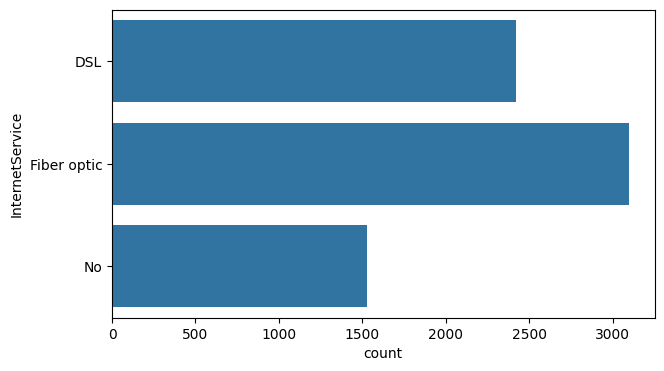

InternetService
Fiber optic    43.958540
DSL            34.374556
No             21.666903
Name: proportion, dtype: float64
--------------------------------------------------




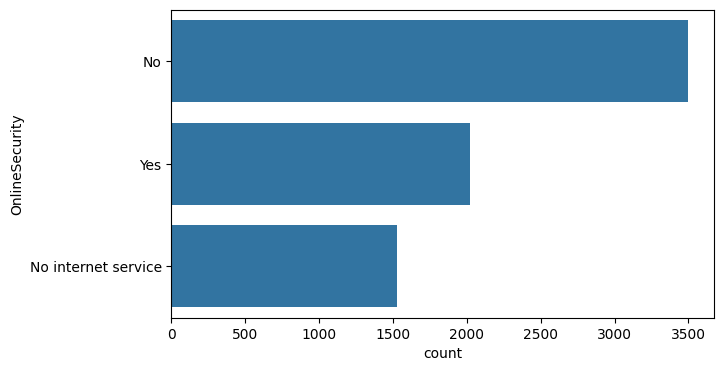

OnlineSecurity
No                     49.666335
Yes                    28.666761
No internet service    21.666903
Name: proportion, dtype: float64
--------------------------------------------------




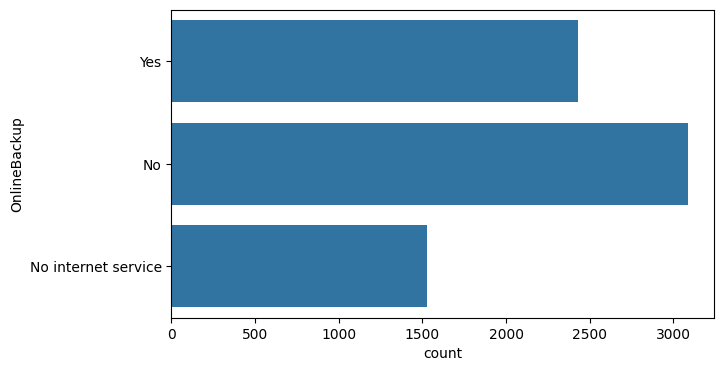

OnlineBackup
No                     43.844952
Yes                    34.488144
No internet service    21.666903
Name: proportion, dtype: float64
--------------------------------------------------




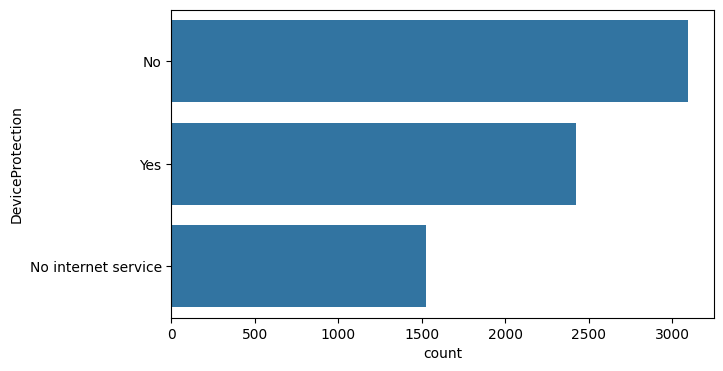

DeviceProtection
No                     43.944342
Yes                    34.388755
No internet service    21.666903
Name: proportion, dtype: float64
--------------------------------------------------




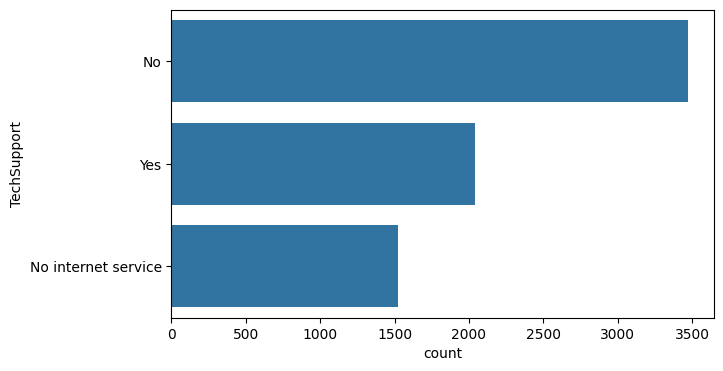

TechSupport
No                     49.311373
Yes                    29.021724
No internet service    21.666903
Name: proportion, dtype: float64
--------------------------------------------------




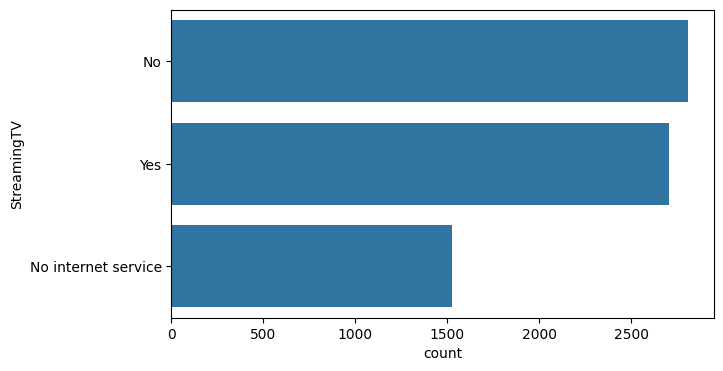

StreamingTV
No                     39.897771
Yes                    38.435326
No internet service    21.666903
Name: proportion, dtype: float64
--------------------------------------------------




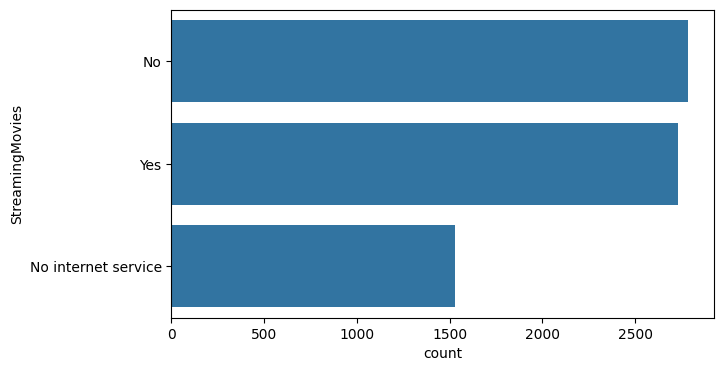

StreamingMovies
No                     39.542808
Yes                    38.790288
No internet service    21.666903
Name: proportion, dtype: float64
--------------------------------------------------




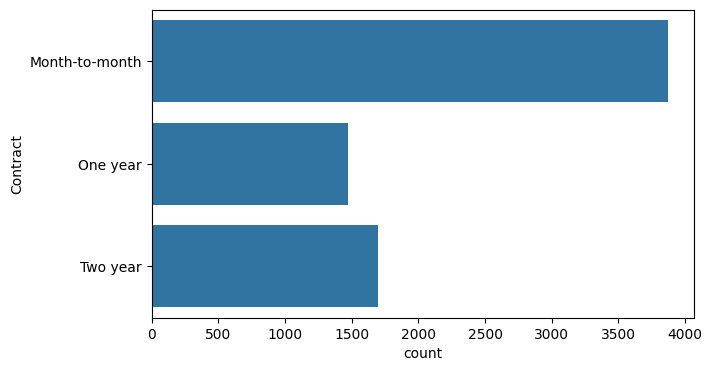

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64
--------------------------------------------------




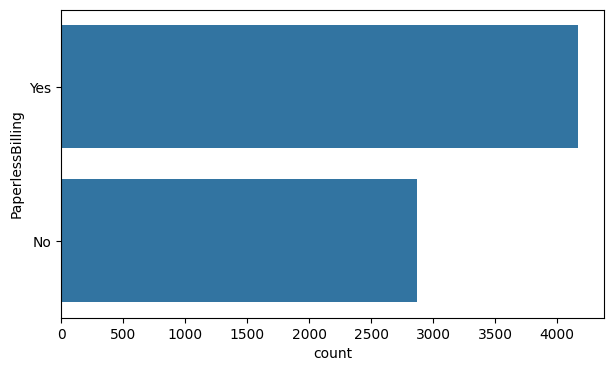

PaperlessBilling
Yes    59.221922
No     40.778078
Name: proportion, dtype: float64
--------------------------------------------------




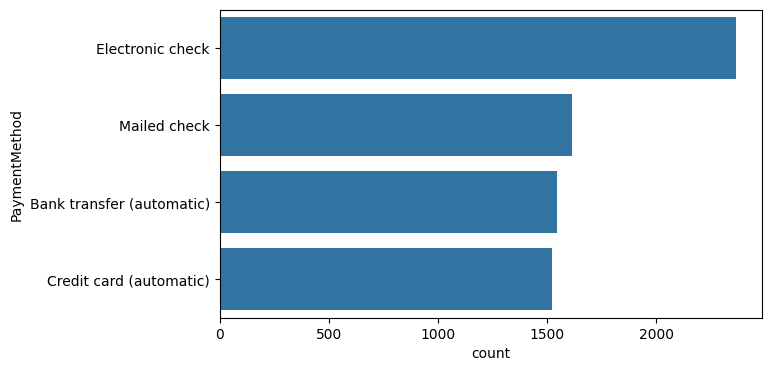

PaymentMethod
Electronic check             33.579441
Mailed check                 22.887974
Bank transfer (automatic)    21.922476
Credit card (automatic)      21.610109
Name: proportion, dtype: float64
--------------------------------------------------




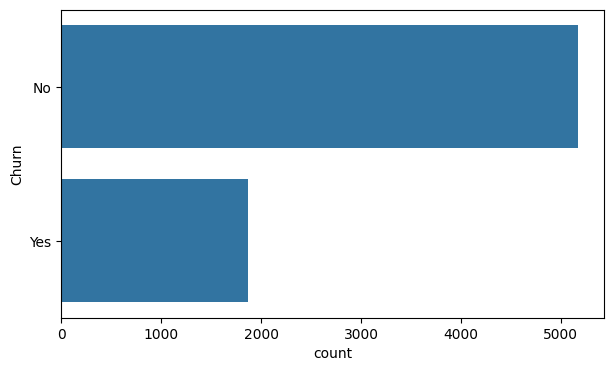

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
--------------------------------------------------




In [26]:
for cols in  cat_cols:
  plt.figure(figsize=(7,4))
  sns.countplot(df[cols])
  plt.show()

  print(df[cols].value_counts(normalize=True)*100)
  print("-"*50)
  print("\n")




/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


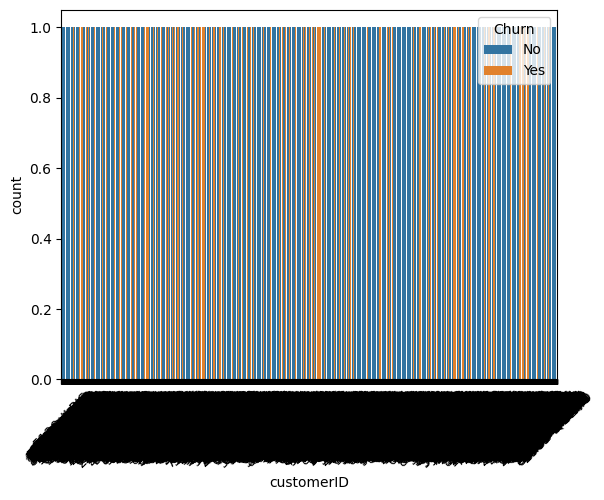

Churn          No    Yes
customerID              
0002-ORFBO  100.0    0.0
0003-MKNFE  100.0    0.0
0004-TLHLJ    0.0  100.0
0011-IGKFF    0.0  100.0
0013-EXCHZ    0.0  100.0
...           ...    ...
9987-LUTYD  100.0    0.0
9992-RRAMN    0.0  100.0
9992-UJOEL  100.0    0.0
9993-LHIEB  100.0    0.0
9995-HOTOH  100.0    0.0

[7043 rows x 2 columns]
--------------------------------------------------




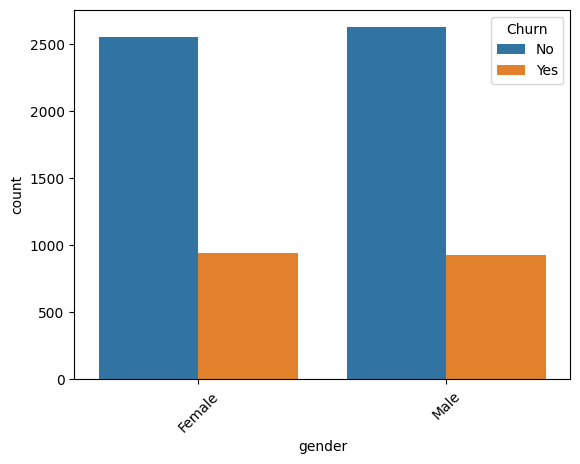

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338
--------------------------------------------------




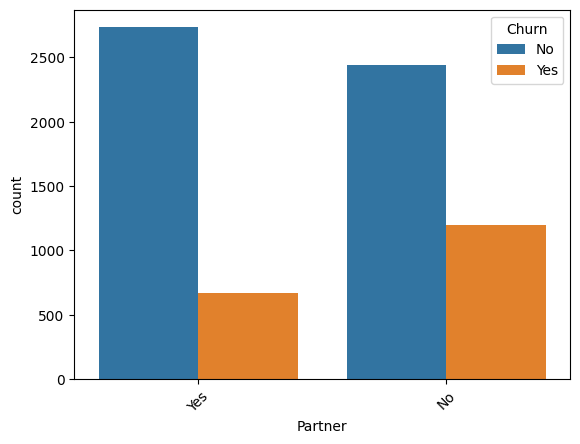

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903
--------------------------------------------------




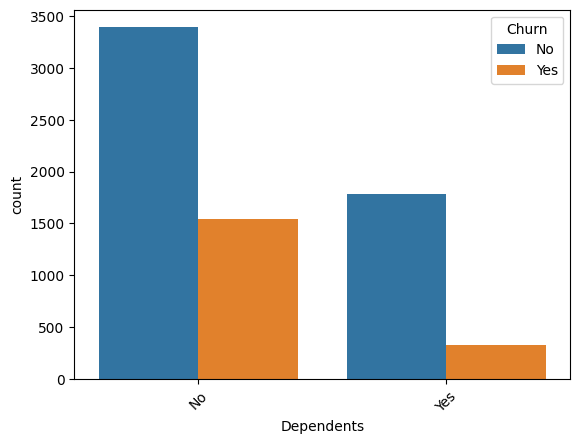

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237
--------------------------------------------------




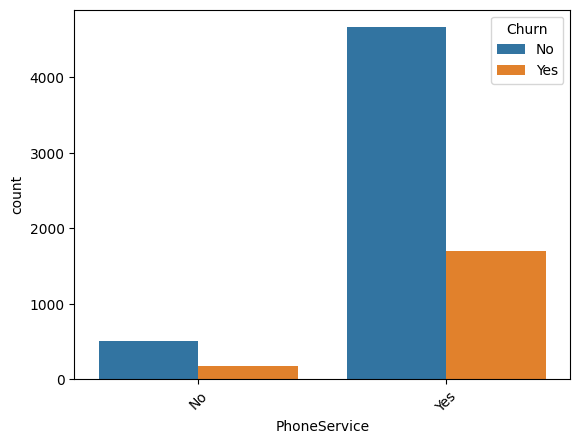

Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637
--------------------------------------------------




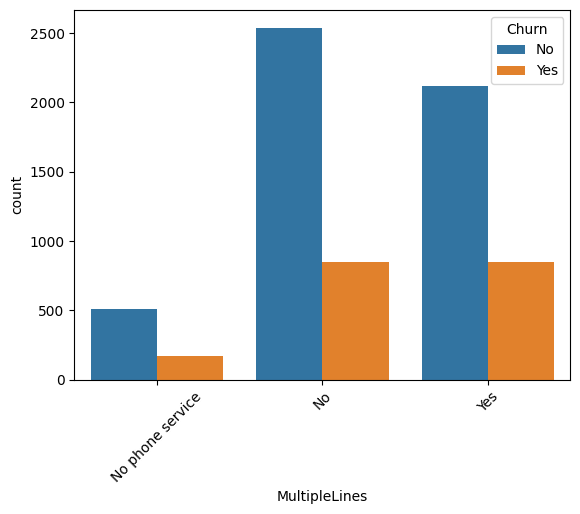

Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896
--------------------------------------------------




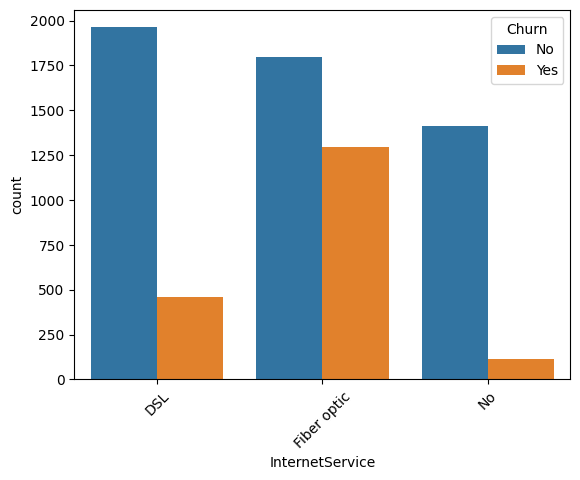

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
--------------------------------------------------




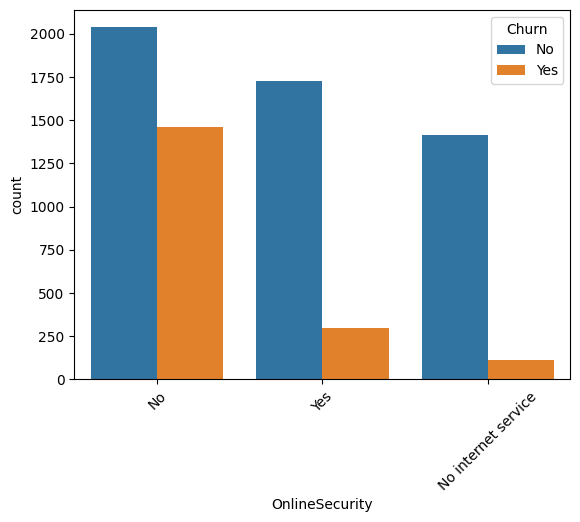

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194
--------------------------------------------------




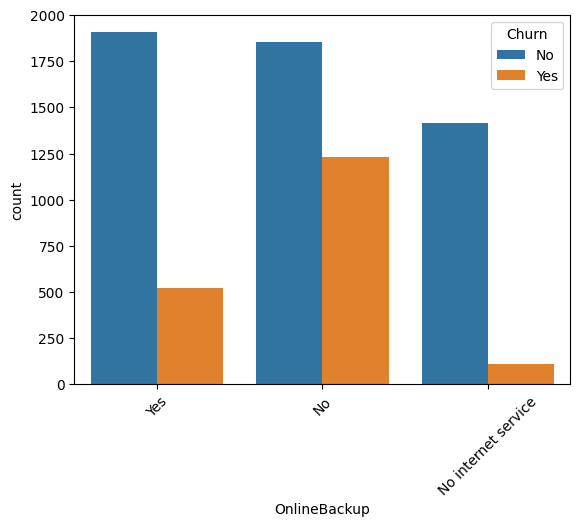

Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494
--------------------------------------------------




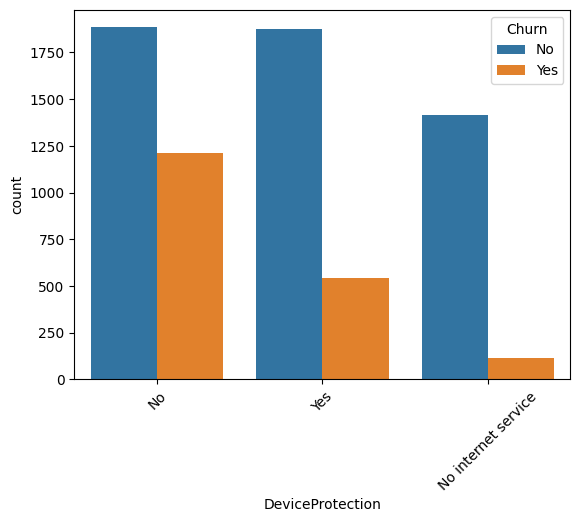

Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064
--------------------------------------------------




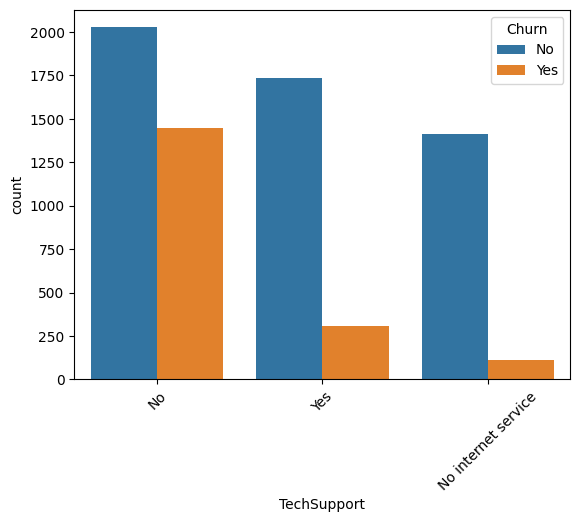

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341
--------------------------------------------------




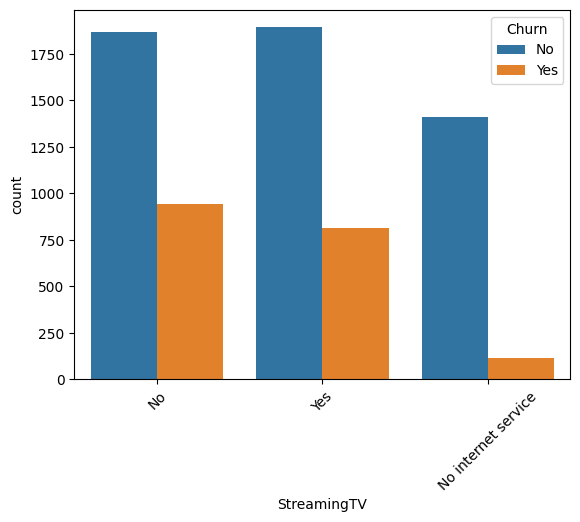

Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188
--------------------------------------------------




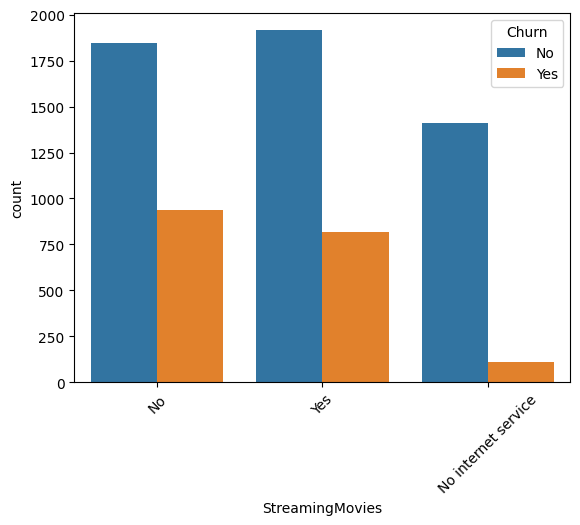

Churn                       No        Yes
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435
--------------------------------------------------




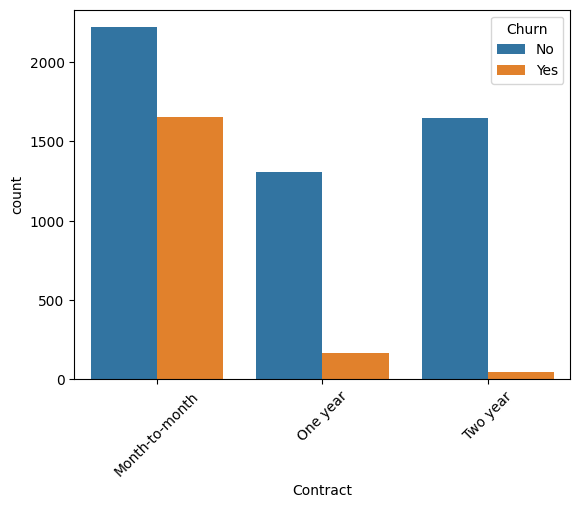

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
--------------------------------------------------




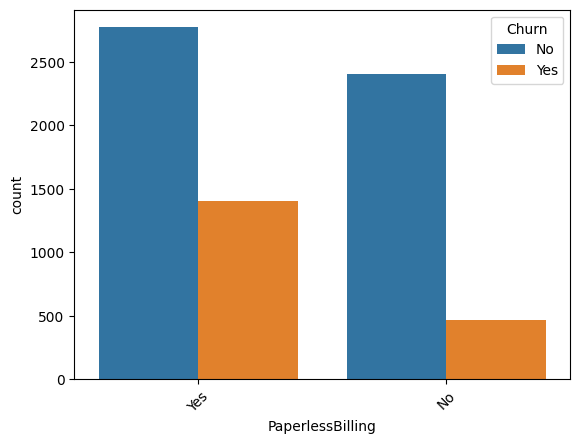

Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092
--------------------------------------------------




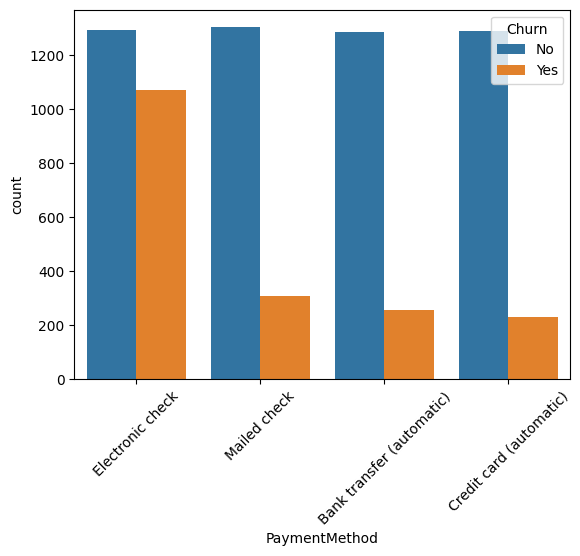

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700
--------------------------------------------------




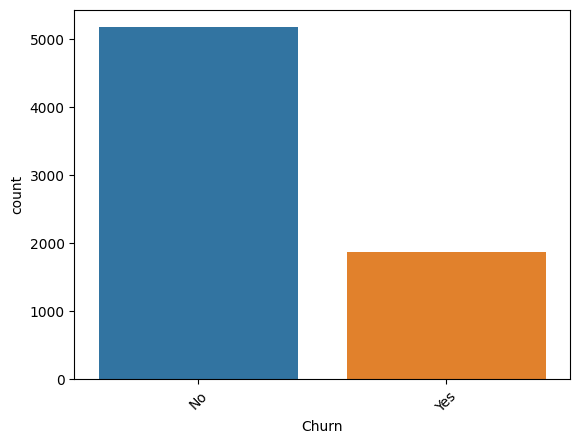

Churn     No    Yes
Churn              
No     100.0    0.0
Yes      0.0  100.0
--------------------------------------------------




In [27]:
for cols in cat_cols:
  sns.countplot(x=cols, hue='Churn', data=df)
  plt.xticks(rotation=45)
  plt.show()

  print(pd.crosstab(df[cols], df['Churn'], normalize='index')*100)
  print("-"*50)
  print("\n")


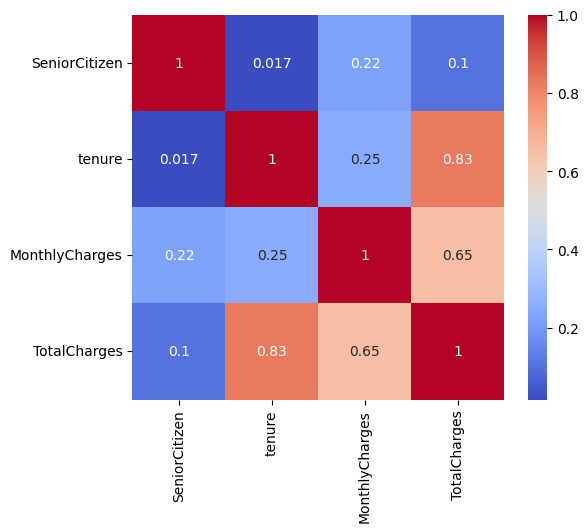

In [28]:
corr = df[num_cols].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

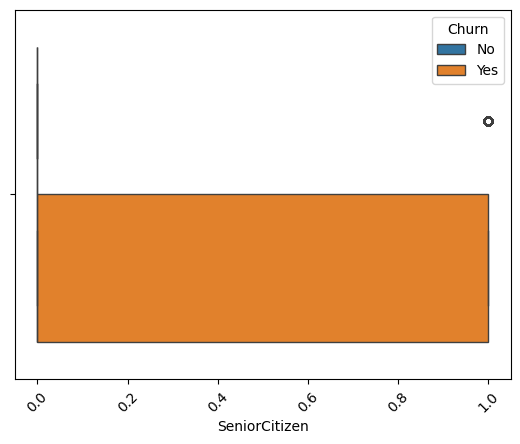

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261
--------------------------------------------------




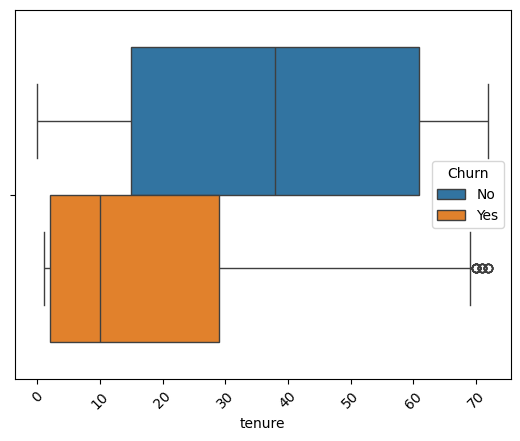

Churn           No        Yes
tenure                       
0       100.000000   0.000000
1        38.009788  61.990212
2        48.319328  51.680672
3        53.000000  47.000000
4        52.840909  47.159091
...            ...        ...
68       91.000000   9.000000
69       91.578947   8.421053
70       90.756303   9.243697
71       96.470588   3.529412
72       98.342541   1.657459

[73 rows x 2 columns]
--------------------------------------------------




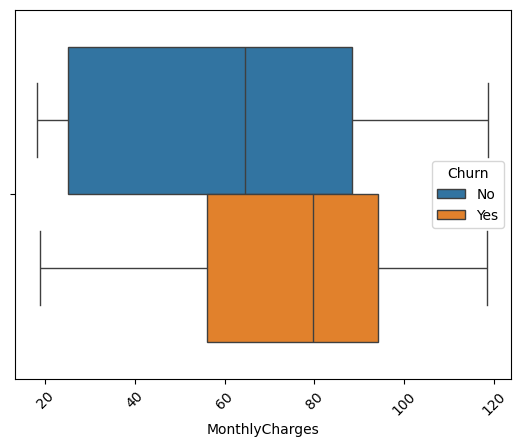

Churn              No    Yes
MonthlyCharges              
18.25           100.0    0.0
18.40           100.0    0.0
18.55           100.0    0.0
18.70           100.0    0.0
18.75           100.0    0.0
...               ...    ...
118.20          100.0    0.0
118.35            0.0  100.0
118.60          100.0    0.0
118.65          100.0    0.0
118.75          100.0    0.0

[1585 rows x 2 columns]
--------------------------------------------------




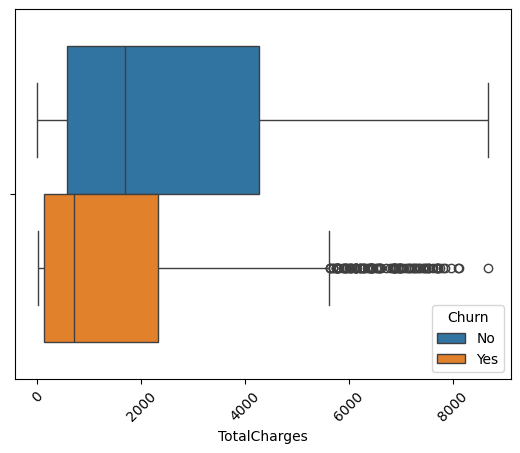

Churn            No    Yes
TotalCharges              
0.00          100.0    0.0
18.80         100.0    0.0
18.85          50.0   50.0
18.90         100.0    0.0
19.00         100.0    0.0
...             ...    ...
8564.75       100.0    0.0
8594.40       100.0    0.0
8670.10       100.0    0.0
8672.45       100.0    0.0
8684.80         0.0  100.0

[6531 rows x 2 columns]
--------------------------------------------------




In [29]:
for cols in num_cols:
  sns.boxplot(x=cols, hue='Churn', data=df)
  plt.xticks(rotation=45)
  plt.show()

  print(pd.crosstab(df[cols], df['Churn'], normalize='index')*100)
  print("-"*50)
  print("\n")

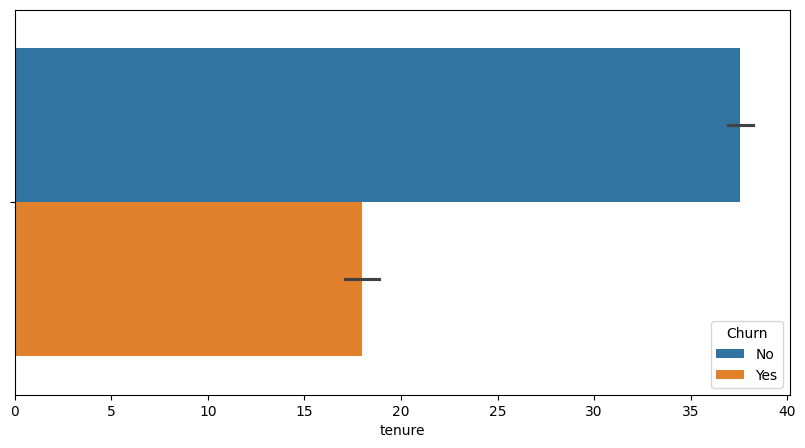

In [30]:
plt.figure(figsize=(10,5))
sns.barplot(x='tenure', hue='Churn', data=df)
plt.show()



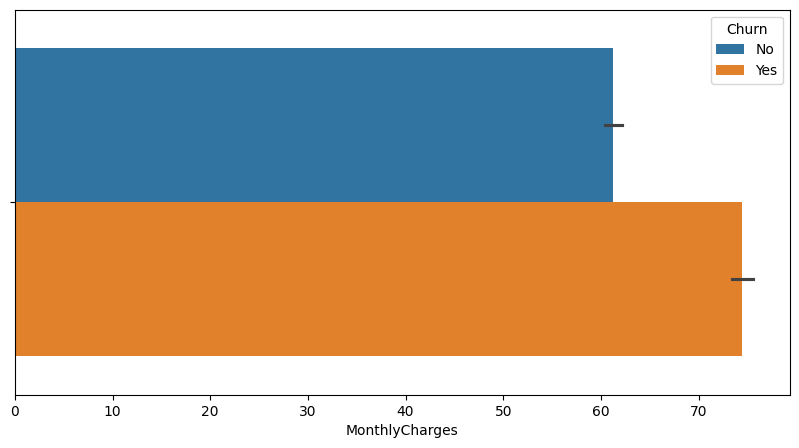

In [31]:
plt.figure(figsize=(10,5))
sns.barplot(x='MonthlyCharges', hue='Churn', data=df)
plt.show()


# FEATURE ENGINEERING


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [33]:
services = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

for col in services:
    df[col] = df[col].replace({
        'Yes':1,
        'No':0,
        'No internet service':0,
        'No phone service':0
    })

df['NumServices'] = df[services].sum(axis=1)

/tmp/ipykernel_410/3725576585.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace({


In [35]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,NumServices,IsNewCustomer
0,7590-VHVEG,Female,0,Yes,No,1,0,0,DSL,0,...,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,1,1
1,5575-GNVDE,Male,0,No,No,34,1,0,DSL,1,...,0,0,One year,No,Mailed check,56.95,1889.50,No,3,0
2,3668-QPYBK,Male,0,No,No,2,1,0,DSL,1,...,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,3,1
3,7795-CFOCW,Male,0,No,No,45,0,0,DSL,1,...,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,3,0
4,9237-HQITU,Female,0,No,No,2,1,0,Fiber optic,0,...,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,1,1,DSL,1,...,1,1,One year,Yes,Mailed check,84.80,1990.50,No,7,0
7039,2234-XADUH,Female,0,Yes,Yes,72,1,1,Fiber optic,0,...,1,1,One year,Yes,Credit card (automatic),103.20,7362.90,No,6,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,0,0,DSL,1,...,0,0,Month-to-month,Yes,Electronic check,29.60,346.45,No,1,1
7041,8361-LTMKD,Male,1,Yes,No,4,1,1,Fiber optic,0,...,0,0,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,2,1


In [34]:
df['IsNewCustomer'] = (df['tenure'] <= 12).astype(int)

## MODEL DEVELOPMENT

### 6.1 Prepare features and target

In [36]:
x = df.drop(['customerID', 'Churn'], axis=1)
y = df['Churn']

In [37]:
x['gender'] = x['gender'].map({'Male' : 1, 'Female' : 0})

In [38]:


binary_cols = [

    'Partner',
    'Dependents',

    'PaperlessBilling'
]

for cols in binary_cols:
  x[cols] = x[cols].map({'Yes':1, 'No':0})



y = y.map({'Yes':1, 'No':0})

In [39]:
x

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumServices,IsNewCustomer
0,0,0,1,0,1,0,0,DSL,0,1,...,0,0,0,Month-to-month,1,Electronic check,29.85,29.85,1,1
1,1,0,0,0,34,1,0,DSL,1,0,...,0,0,0,One year,0,Mailed check,56.95,1889.50,3,0
2,1,0,0,0,2,1,0,DSL,1,1,...,0,0,0,Month-to-month,1,Mailed check,53.85,108.15,3,1
3,1,0,0,0,45,0,0,DSL,1,0,...,1,0,0,One year,0,Bank transfer (automatic),42.30,1840.75,3,0
4,0,0,0,0,2,1,0,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Electronic check,70.70,151.65,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,24,1,1,DSL,1,0,...,1,1,1,One year,1,Mailed check,84.80,1990.50,7,0
7039,0,0,1,1,72,1,1,Fiber optic,0,1,...,0,1,1,One year,1,Credit card (automatic),103.20,7362.90,6,0
7040,0,0,1,1,11,0,0,DSL,1,0,...,0,0,0,Month-to-month,1,Electronic check,29.60,346.45,1,1
7041,1,1,1,0,4,1,1,Fiber optic,0,0,...,0,0,0,Month-to-month,1,Mailed check,74.40,306.60,2,1


In [40]:

x_original = x.copy()

### 6.2 Train/test split

In [41]:
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

x_train_check, x_test_check, y_train_check, y_test_check = train_test_split(
    x_original,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [42]:
print(x_test_check.shape)

(1409, 21)


### 6.3 Encode categorical features

In [43]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

cet_cols = ['InternetService',
    'Contract',
    'PaymentMethod']

ct = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cet_cols)
], remainder='passthrough')



In [44]:
x_train = ct.fit_transform(x_train)

In [45]:
x_test = ct.transform(x_test)

## 7. Baseline Random Forest Model

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'
)

rf_balanced.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [47]:
pred = rf_balanced.predict(x_test)

In [48]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [49]:
print(accuracy_score(y_test, pred))
print(precision_score(y_test, pred))
print(recall_score(y_test, pred))
print(f1_score(y_test, pred))
print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))

0.7863733144073811
0.6298932384341637
0.4732620320855615
0.5404580152671755
[[931 104]
 [197 177]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409



In [50]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(
    RandomForestClassifier(random_state=42),
    x_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("CV Scores:", cv)
print("Mean CV Accuracy:", cv.mean())
print("Std:", cv.std())

CV Scores: [0.79503106 0.80212955 0.78172138 0.77905945 0.77975133]
Mean CV Accuracy: 0.7875385539187487
Std: 0.009331775508162178


In [51]:
import pandas as pd

feature_names = ct.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_balanced.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(15))

                                Feature  Importance
21            remainder__MonthlyCharges    0.161460
22              remainder__TotalCharges    0.154225
11                    remainder__tenure    0.136673
3                ohe__Contract_Two year    0.076597
0      ohe__InternetService_Fiber optic    0.041696
24             remainder__IsNewCustomer    0.039500
5   ohe__PaymentMethod_Electronic check    0.039238
23               remainder__NumServices    0.038495
2                ohe__Contract_One year    0.034193
20          remainder__PaperlessBilling    0.025601
7                     remainder__gender    0.024614
1               ohe__InternetService_No    0.021748
9                    remainder__Partner    0.021388
14            remainder__OnlineSecurity    0.020805
10                remainder__Dependents    0.018720


## 8. Random Forest Hyperparameter Tuning

In [52]:
param_grid = {
    'n_estimators': [100, 200, 300],

    'max_depth': [10, 15, 20, None],

    'min_samples_split': [2, 5, 10],

    'min_samples_leaf': [1, 2, 4]
}

In [53]:
from sklearn.model_selection import GridSearchCV

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs = -1
    )

In [55]:
grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 15, 20, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy')

In [56]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
0.7996080384428079


In [57]:
best_model = grid_search.best_estimator_
best_model

pred = best_model.predict(x_test)

print(accuracy_score(y_test, pred))

0.8019872249822569


In [58]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy :", accuracy_score(y_test, pred))

print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy : 0.8019872249822569
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409

[[941  94]
 [185 189]]


In [59]:
probs = best_model.predict_proba(x_test)[:, 1]
threshold = 0.43
y_pred_new = (probs >= threshold).astype(int)

In [60]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_new))
print(classification_report(y_test, y_pred_new))

[[901 134]
 [147 227]]
              precision    recall  f1-score   support

           0       0.86      0.87      0.87      1035
           1       0.63      0.61      0.62       374

    accuracy                           0.80      1409
   macro avg       0.74      0.74      0.74      1409
weighted avg       0.80      0.80      0.80      1409



AUC Score: 0.8424164922886151


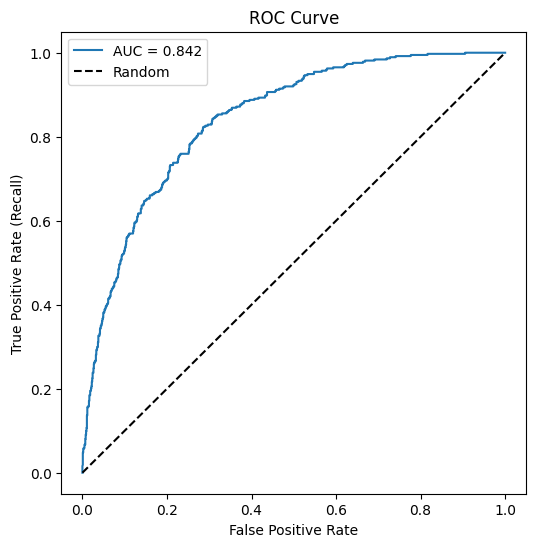

In [61]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability of the positive class (Churn = Yes)
y_prob = best_model.predict_proba(x_test)[:, 1]

# ROC points
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC Score
auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

# Plot ROC
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")

# Random classifier line
plt.plot([0,1],[0,1],'k--',label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 9. XGBoost Model — *commented out, not used*

This project uses **Random Forest** as the model going forward. The XGBoost cells below are kept for reference but commented out so they don't run. `best_model` (the tuned Random Forest from Section 8) is used everywhere downstream instead of an XGBoost model.

In [ ]:
# from xgboost import XGBClassifier

In [ ]:
# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric='logloss'
# )

In [ ]:
# xgb.fit(x_train, y_train)

In [ ]:
# y_pred = xgb.predict(x_test)

In [ ]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     classification_report
# )
#
# print("Accuracy :", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall   :", recall_score(y_test, y_pred))
# print("F1 Score :", f1_score(y_test, y_pred))
#
# print(confusion_matrix(y_test, y_pred))
#
# print(classification_report(y_test, y_pred))

In [ ]:
# from sklearn.model_selection import cross_val_score
#
# scores = cross_val_score(
#     xgb,
#     x_train,
#     y_train,
#     cv=5,
#     scoring='accuracy'
# )
#
# print(scores)
# print(scores.mean())

In [ ]:
# from sklearn.metrics import roc_auc_score
#
# y_prob = xgb.predict_proba(x_test)[:,1]
#
# auc = roc_auc_score(y_test, y_prob)
#
# print("AUC:", auc)

## 10. XGBoost Hyperparameter Tuning — *commented out, not used*

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from xgboost import XGBClassifier
#
# xgb = XGBClassifier(
#     random_state=42,
#     eval_metric='logloss'
# )
#
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'subsample': [0.8, 1.0],
#     'colsample_bytree': [0.8, 1.0]
# }
#
# grid = GridSearchCV(
#     estimator=xgb,
#     param_grid=param_grid,
#     cv=5,
#     scoring='f1',
#     n_jobs=-1,
#     verbose=1
# )
#
# grid.fit(x_train, y_train)
#
# print("Best Parameters:", grid.best_params_)
# print("Best CV Score:", grid.best_score_)

In [ ]:
# best_xgb = grid.best_estimator_
#
# y_prob = best_xgb.predict_proba(x_test)[:,1]
#
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     classification_report,
#     roc_auc_score
# )
#
# print("Accuracy :", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall   :", recall_score(y_test, y_pred))
# print("F1 Score :", f1_score(y_test, y_pred))
#
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))
#
# y_prob = best_xgb.predict_proba(x_test)[:, 1]
# print("ROC-AUC :", roc_auc_score(y_test, y_prob))

In [ ]:
# threshold = 0.43
#
# y_pred = (y_prob >= threshold).astype(int)

In [ ]:
# print(confusion_matrix(y_test, y_pred))
# print(classification_report(y_test, y_pred))

## 11. Model Interpretability (SHAP)

In [62]:
import shap

In [63]:
explainer = shap.TreeExplainer(best_model)

In [64]:
shap_values = explainer.shap_values(x_test)

In [ ]:
shap.summary_plot(
    shap_values,
    x_test,
    feature_names=ct.get_feature_names_out()
)

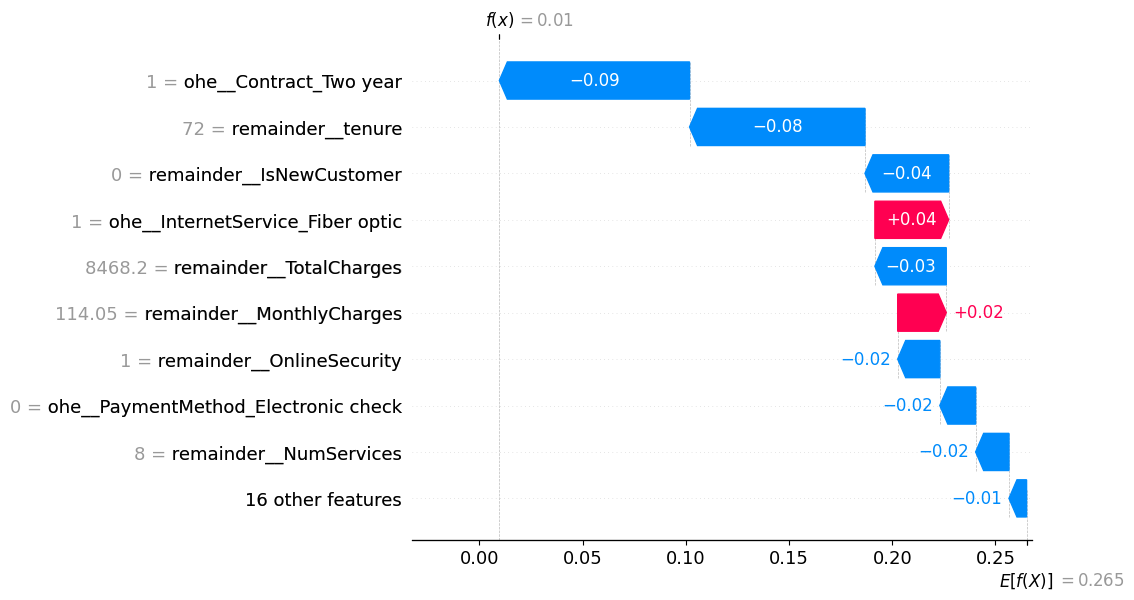

In [65]:
import pandas as pd

feature_names = ct.get_feature_names_out()

x_test_df = pd.DataFrame(
    x_test,
    columns=feature_names
)

exp = explainer(x_test_df)

shap.plots.waterfall(exp[0, :, 1])

In [66]:
exp = explainer(x_test)

print(exp.shape)

(1409, 25, 2)


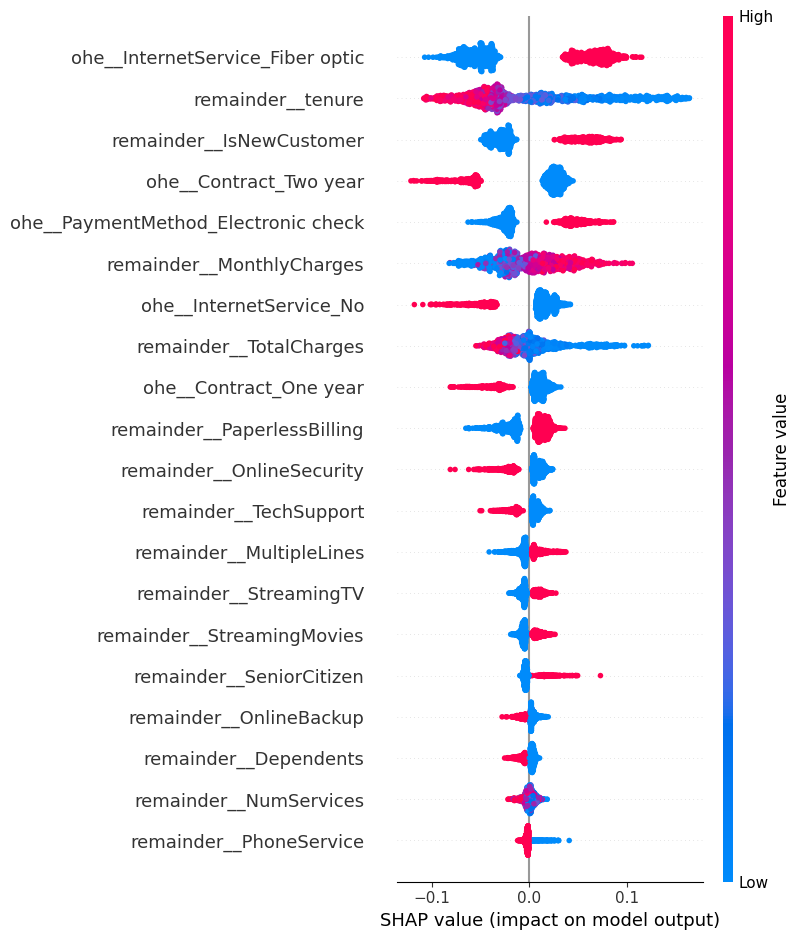

In [67]:
exp = explainer(x_test)

shap.summary_plot(
    exp[:, :, 1],
    x_test,
    feature_names=ct.get_feature_names_out()
)

## 12. Business Risk Analysis

### 12.1 Build the risk table

In [68]:
import pandas as pd

risk_df = pd.DataFrame({
    "Churn_Probability": y_prob
})

def risk_level(prob):
    if prob >= 0.80:
        return "Critical"
    elif prob >= 0.60:
        return "High"
    elif prob >= 0.30:
        return "Medium"
    else:
        return "Low"

risk_df["Risk_Level"] = risk_df["Churn_Probability"].apply(risk_level)

risk_df.head()


,Churn_Probability,Risk_Level
0,0.009635,Low
1,0.813131,Critical
2,0.090100,Low
3,0.349994,Medium
4,0.019694,Low


In [69]:
risk_df["MonthlyCharges"] = x_test_check["MonthlyCharges"].values
risk_df["tenure"] = x_test_check["tenure"].values
risk_df["Contract"] = x_test_check["Contract"].values

In [70]:
risk_df.head()

,Churn_Probability,Risk_Level,MonthlyCharges,tenure,Contract
0,0.009635,Low,114.05,72,Two year
1,0.813131,Critical,100.15,8,Month-to-month
2,0.090100,Low,78.35,41,One year
3,0.349994,Medium,78.20,18,Month-to-month
4,0.019694,Low,82.65,72,Two year


In [71]:
risk_df.shape

(1409, 5)

In [72]:
risk_df["Risk_Level"].value_counts()

,count
Risk_Level,
Low,862
Medium,383
High,116
Critical,48


### 12.2 Recommended actions & prediction outcomes

In [73]:
def business_action(risk):

    if risk=="Critical":
        return "Immediate retention call + Discount"

    elif risk=="High":
        return "Special Offer"

    elif risk=="Medium":
        return "Email Promotion"

    else:
        return "No Action"

risk_df["Recommended_Action"] = risk_df["Risk_Level"].apply(business_action)

In [74]:
risk_df["Actual"] = y_test.values

In [75]:
risk_df["Prediction"] = pred

In [76]:
type(x_test)

numpy.ndarray

In [77]:
x_test.shape

(1409, 25)

In [78]:
x.shape

(7043, 21)

In [79]:
x_test.shape

(1409, 25)

In [80]:
risk_df["Risk_Level"].value_counts()

,count
Risk_Level,
Low,862
Medium,383
High,116
Critical,48


### 12.3 Risk segment profiling

In [81]:
risk_df.groupby("Risk_Level")["MonthlyCharges"].mean()

,MonthlyCharges
Risk_Level,
Critical,84.670833
High,77.894397
Low,57.548608
Medium,72.047911


In [82]:
risk_df.groupby("Risk_Level")["tenure"].mean()

,tenure
Risk_Level,
Critical,2.333333
High,5.663793
Low,42.703016
Medium,19.295039


In [83]:
pd.crosstab(risk_df["Risk_Level"], risk_df["Contract"])

Contract,Month-to-month,One year,Two year
Risk_Level,,,
Critical,48,0,0
High,114,2,0
Low,250,278,334
Medium,361,20,2


In [84]:
risk_df.groupby("Contract")["Churn_Probability"].mean()

,Churn_Probability
Contract,
Month-to-month,0.416948
One year,0.134375
Two year,0.045735


In [85]:
risk_df.groupby("Risk_Level")["Actual"].mean()

,Actual
Risk_Level,
Critical,0.791667
High,0.724138
Low,0.102088
Medium,0.428198


### 12.4 Revenue at risk

In [86]:
risk_df["Expected_Revenue_Loss"] = (
    risk_df["MonthlyCharges"] *
    risk_df["Churn_Probability"]
)

In [87]:
total_loss = risk_df["Expected_Revenue_Loss"].sum()

print(f"Estimated Monthly Revenue at Risk: ₹{total_loss:.2f}")

Estimated Monthly Revenue at Risk: ₹27876.67


In [88]:
top_loss = risk_df.sort_values(
    by="Expected_Revenue_Loss",
    ascending=False
)

top_loss.head(10)

,Churn_Probability,Risk_Level,MonthlyCharges,tenure,Contract,Recommended_Action,Actual,Prediction,Expected_Revenue_Loss
1164,0.874005,Critical,101.95,7,Month-to-month,Immediate retention call + Discount,1,1,89.104822
1175,0.890630,Critical,99.25,7,Month-to-month,Immediate retention call + Discount,1,1,88.395013
1090,0.924141,Critical,95.10,1,Month-to-month,Immediate retention call + Discount,1,1,87.885762
647,0.869659,Critical,100.95,3,Month-to-month,Immediate retention call + Discount,1,1,87.792034
1221,0.912313,Critical,95.45,1,Month-to-month,Immediate retention call + Discount,1,1,87.080263
1138,0.807610,Critical,105.90,3,Month-to-month,Immediate retention call + Discount,1,1,85.525857
1188,0.865764,Critical,98.05,7,Month-to-month,Immediate retention call + Discount,1,1,84.888124
630,0.797935,High,105.30,6,Month-to-month,Special Offer,1,1,84.022559
627,0.848929,Critical,96.60,3,Month-to-month,Immediate retention call + Discount,1,1,82.006566
710,0.856718,Critical,95.65,1,Month-to-month,Immediate retention call + Discount,1,1,81.945118


In [89]:
risk_df.groupby("Risk_Level")["Expected_Revenue_Loss"].sum()

,Expected_Revenue_Loss
Risk_Level,
Critical,3466.304644
High,6266.985818
Low,5868.742407
Medium,12274.636970


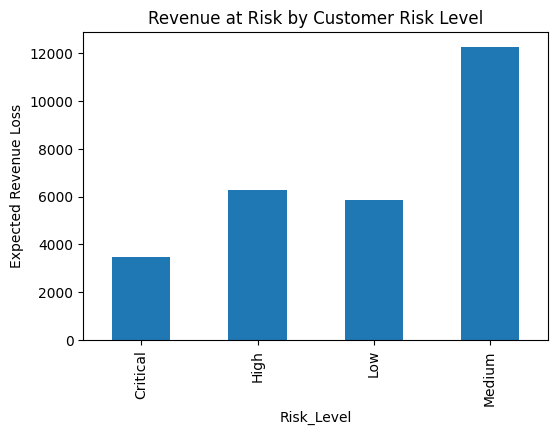

In [90]:
import matplotlib.pyplot as plt

loss = risk_df.groupby("Risk_Level")["Expected_Revenue_Loss"].sum()

plt.figure(figsize=(6,4))
loss.plot(kind="bar")
plt.title("Revenue at Risk by Customer Risk Level")
plt.ylabel("Expected Revenue Loss")
plt.show()

In [91]:
risk_df.groupby("Risk_Level")["MonthlyCharges"].mean()

,MonthlyCharges
Risk_Level,
Critical,84.670833
High,77.894397
Low,57.548608
Medium,72.047911


In [92]:
potential_saved = total_loss * 0.40
print(f"Potential Monthly Revenue Saved: ₹{potential_saved:.2f}")

Potential Monthly Revenue Saved: ₹11150.67


In [93]:
risk_df["Expected_Revenue_Loss"]

,Expected_Revenue_Loss
0,1.098825
1,81.435104
2,7.059355
3,27.369547
4,1.627704
...,...
1404,8.174048
1405,0.200914
1406,2.035038
1407,1.185813


### 12.5 Summary dashboard & visuals

In [94]:
total_customers = len(risk_df)

critical = (risk_df["Risk_Level"]=="Critical").sum()
high = (risk_df["Risk_Level"]=="High").sum()
medium = (risk_df["Risk_Level"]=="Medium").sum()
low = (risk_df["Risk_Level"]=="Low").sum()

avg_probability = risk_df["Churn_Probability"].mean()

total_revenue_risk = risk_df["Expected_Revenue_Loss"].sum()

print("Total Customers :", total_customers)
print("Critical :", critical)
print("High :", high)
print("Medium :", medium)
print("Low :", low)
print("Average Probability :", round(avg_probability,3))
print("Revenue At Risk : ₹", round(total_revenue_risk,2))

Total Customers : 1409
Critical : 48
High : 116
Medium : 383
Low : 862
Average Probability : 0.268
Revenue At Risk : ₹ 27876.67


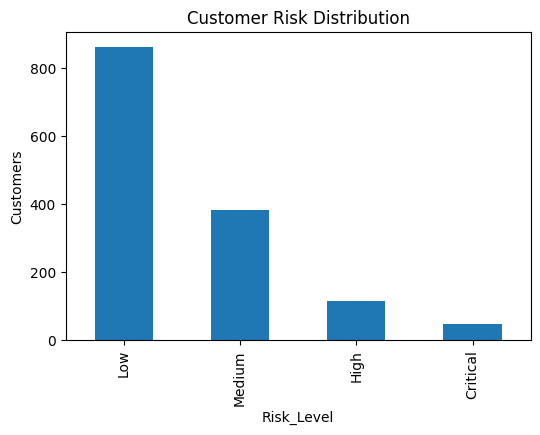

In [95]:
import matplotlib.pyplot as plt

risk_df["Risk_Level"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Customer Risk Distribution")
plt.ylabel("Customers")
plt.show()

In [96]:
pd.crosstab(
    risk_df["Risk_Level"],
    risk_df["Contract"]
)

Contract,Month-to-month,One year,Two year
Risk_Level,,,
Critical,48,0,0
High,114,2,0
Low,250,278,334
Medium,361,20,2


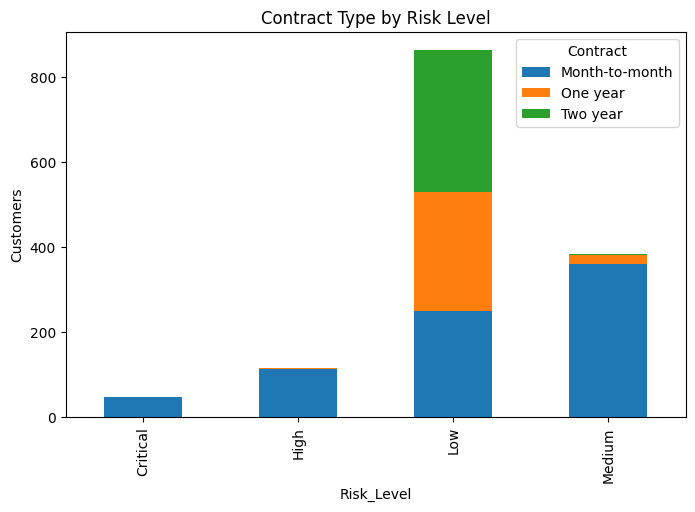

In [97]:
pd.crosstab(
    risk_df["Risk_Level"],
    risk_df["Contract"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Contract Type by Risk Level")
plt.ylabel("Customers")
plt.show()

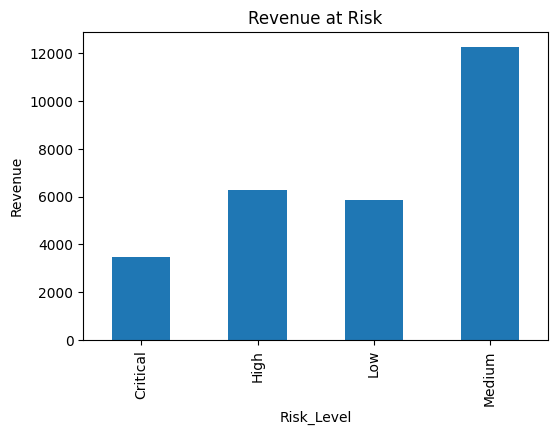

In [98]:
risk_df.groupby(
    "Risk_Level"
)["Expected_Revenue_Loss"].sum().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Revenue at Risk")
plt.ylabel("Revenue")
plt.show()

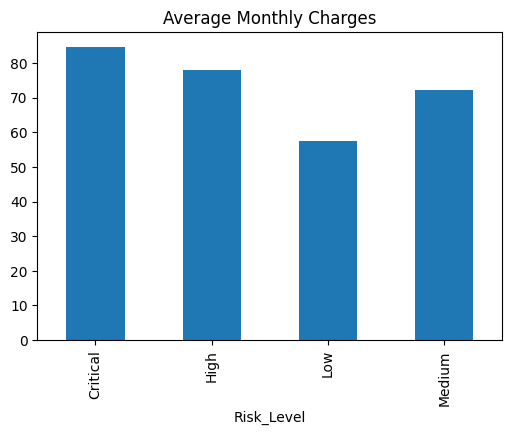

In [99]:
risk_df.groupby(
    "Risk_Level"
)["MonthlyCharges"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Monthly Charges")
plt.show()

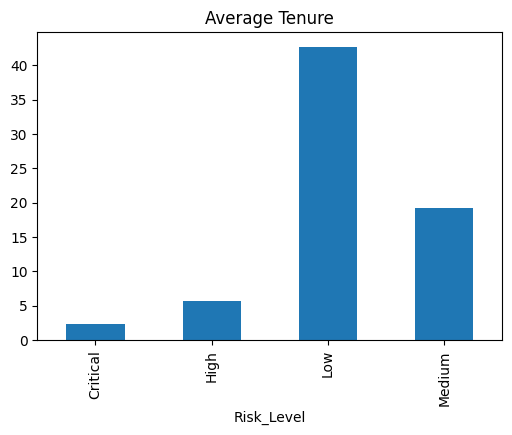

In [100]:
risk_df.groupby(
    "Risk_Level"
)["tenure"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Tenure")
plt.show()

In [101]:
top20 = risk_df.sort_values(
    by="Expected_Revenue_Loss",
    ascending=False
)

top20.head(20)

,Churn_Probability,Risk_Level,MonthlyCharges,tenure,Contract,Recommended_Action,Actual,Prediction,Expected_Revenue_Loss
1164,0.874005,Critical,101.95,7,Month-to-month,Immediate retention call + Discount,1,1,89.104822
1175,0.890630,Critical,99.25,7,Month-to-month,Immediate retention call + Discount,1,1,88.395013
1090,0.924141,Critical,95.10,1,Month-to-month,Immediate retention call + Discount,1,1,87.885762
647,0.869659,Critical,100.95,3,Month-to-month,Immediate retention call + Discount,1,1,87.792034
1221,0.912313,Critical,95.45,1,Month-to-month,Immediate retention call + Discount,1,1,87.080263
1138,0.807610,Critical,105.90,3,Month-to-month,Immediate retention call + Discount,1,1,85.525857
1188,0.865764,Critical,98.05,7,Month-to-month,Immediate retention call + Discount,1,1,84.888124
630,0.797935,High,105.30,6,Month-to-month,Special Offer,1,1,84.022559
627,0.848929,Critical,96.60,3,Month-to-month,Immediate retention call + Discount,1,1,82.006566
710,0.856718,Critical,95.65,1,Month-to-month,Immediate retention call + Discount,1,1,81.945118


In [102]:
dashboard = {
    "Total Customers": total_customers,
    "Critical Customers": critical,
    "Revenue At Risk": total_revenue_risk,
    "Average Churn Probability": avg_probability
}

dashboard

{'Total Customers': 1409,
 'Critical Customers': np.int64(48),
 'Revenue At Risk': np.float64(27876.669839452785),
 'Average Churn Probability': np.float64(0.26826119714849894)}

In [103]:
risk_df["Priority_Score"] = (
    risk_df["Churn_Probability"] *
    risk_df["MonthlyCharges"]
)
risk_df.sort_values(
    by="Priority_Score",
    ascending=False
).head(10)

,Churn_Probability,Risk_Level,MonthlyCharges,tenure,Contract,Recommended_Action,Actual,Prediction,Expected_Revenue_Loss,Priority_Score
1164,0.874005,Critical,101.95,7,Month-to-month,Immediate retention call + Discount,1,1,89.104822,89.104822
1175,0.890630,Critical,99.25,7,Month-to-month,Immediate retention call + Discount,1,1,88.395013,88.395013
1090,0.924141,Critical,95.10,1,Month-to-month,Immediate retention call + Discount,1,1,87.885762,87.885762
647,0.869659,Critical,100.95,3,Month-to-month,Immediate retention call + Discount,1,1,87.792034,87.792034
1221,0.912313,Critical,95.45,1,Month-to-month,Immediate retention call + Discount,1,1,87.080263,87.080263
1138,0.807610,Critical,105.90,3,Month-to-month,Immediate retention call + Discount,1,1,85.525857,85.525857
1188,0.865764,Critical,98.05,7,Month-to-month,Immediate retention call + Discount,1,1,84.888124,84.888124
630,0.797935,High,105.30,6,Month-to-month,Special Offer,1,1,84.022559,84.022559
627,0.848929,Critical,96.60,3,Month-to-month,Immediate retention call + Discount,1,1,82.006566,82.006566
710,0.856718,Critical,95.65,1,Month-to-month,Immediate retention call + Discount,1,1,81.945118,81.945118


## 13. Final Pipeline & Model Export

In [104]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessor", ct),
    ("model", best_model)
])

In [105]:
pipeline.fit(x_train_check, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['InternetService',
                                                   'Contract',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(max_depth=10, min_samples_leaf=4,
                                        min_samples_split=10, n_estimators=200,
                                        random_state=42))])

In [106]:
print(type(x_train_check))
print(x_train_check.shape)
print(x_train_check.head())

<class 'pandas.core.frame.DataFrame'>
(5634, 21)
      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
3738       1              0        0           0      35             0   
3151       1              0        1           1      15             1   
4860       1              0        1           1      13             0   
3867       0              0        1           0      26             1   
3810       1              0        1           1       1             1   

      MultipleLines InternetService  OnlineSecurity  OnlineBackup  ...  \
3738              0             DSL               0             0  ...   
3151              0     Fiber optic               1             0  ...   
4860              0             DSL               1             1  ...   
3867              0             DSL               0             1  ...   
3810              0             DSL               0             0  ...   

      TechSupport  StreamingTV  StreamingMovies        Contra

In [107]:
y_pred = pipeline.predict(x_test_check)

y_prob = pipeline.predict_proba(x_test_check)[:, 1]

In [108]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8019872249822569
ROC-AUC: 0.8424164922886151
[[941  94]
 [185 189]]
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [109]:
import joblib

joblib.dump(pipeline, "telecom_churn_pipeline.pkl")

['telecom_churn_pipeline.pkl']

In [110]:
model = joblib.load("telecom_churn_pipeline.pkl")

In [111]:
prediction = model.predict(x_test_check.iloc[[0]])

probability = model.predict_proba(x_test_check.iloc[[0]])

In [112]:
print("Prediction:", prediction)
print("Probability:", probability)

Prediction: [0]
Probability: [[0.99036541 0.00963459]]


In [113]:
sample = x_test_check.iloc[[10]]

sample

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,NumServices,IsNewCustomer
2079,1,0,1,1,70,1,1,Fiber optic,1,1,...,0,1,1,Month-to-month,1,Electronic check,106.05,7554.05,6,0


In [114]:
model.predict(sample)

model.predict_proba(sample)

array([[0.80603543, 0.19396457]])